# Chapter 9 — Fundamentals of Sensor Technology: Hands-On Python Practice
## *Fundamentals of the Internet of Things*
**Oleksandr Kuznetsov** · eCampus University, Novedrate (CO), Italy

---

> **How to use this notebook.** Each exercise is self-contained: read the
> background, run the code cells in order, study the plots, then try the
> challenge tasks at the end of each section. All exercises run in Google
> Colab with no additional hardware. The first three code cells generate
> the conceptual diagrams used in Section 9.2 of the chapter; Exercises
> 9.1–9.4 then generate the four data figures used in Section 9.3.

| Section | Topic | Key idea |
|---|---|---|
| Setup | Theory illustrations | Measurement chain, transfer characteristic, step response ↔ bandwidth |
| 9.1 | Accuracy, precision, resolution | Bias, repeatability, and resolution leave different signatures |
| 9.2 | Static transfer characteristic | Sensitivity, nonlinearity, and hysteresis from a bidirectional sweep |
| 9.3 | Dynamic response | Time constant, rise time, and $-3$ dB bandwidth |
| 9.4 | Noise and detectability | Input-referred noise and the change needed for 95% detection |


---
## Setup

A single reproducible random generator, `rng = np.random.default_rng(42)`,
is used for every stochastic experiment in this notebook. There is no
separate call to the legacy global `np.random.seed`, so there is exactly
one source of randomness to reason about.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from math import erf

plt.rcParams.update({
    'figure.figsize': (10, 4.2),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9.5,
    'lines.linewidth': 1.8,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
})

rng = np.random.default_rng(42)   # the only random-number source used in this notebook


---
## Theory illustration 1 — The measurement chain (Figure 9.1)

Every sensor indication passes through several stages between the physical
measurand and the final digital reading, and each stage can add its own
error, delay, or noise. This figure is generated here and placed in
Section 9.2.1 of the chapter.

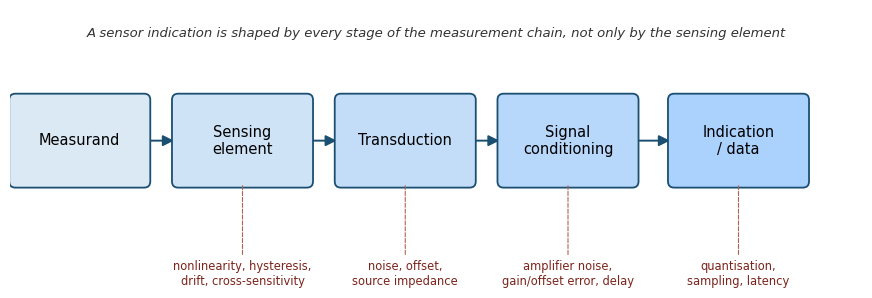

In [2]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.set_xlim(0, 11)
ax.set_ylim(0, 3.6)
ax.axis('off')

stages = ['Measurand', 'Sensing\nelement', 'Transduction', 'Signal\nconditioning', 'Indication\n/ data']
xs = [0.9, 3.0, 5.1, 7.2, 9.4]
w, h = 1.7, 1.1
colors = ['#dbe9f5', '#cfe3f7', '#c3ddf9', '#b7d7fb', '#abd1fd']
for x, label, c in zip(xs, stages, colors):
    box = FancyBboxPatch((x - w/2, 1.9 - h/2), w, h,
                          boxstyle="round,pad=0.06,rounding_size=0.08",
                          linewidth=1.3, edgecolor='#1b4f72', facecolor=c, zorder=3)
    ax.add_patch(box)
    ax.text(x, 1.9, label, ha='center', va='center', fontsize=10.5, zorder=4)

for i in range(len(xs) - 1):
    arr = FancyArrowPatch((xs[i] + w/2, 1.9), (xs[i+1] - w/2, 1.9),
                           arrowstyle='-|>', mutation_scale=16, linewidth=1.4, color='#1b4f72', zorder=2)
    ax.add_patch(arr)

annots = [
    (3.0, 'nonlinearity, hysteresis,\ndrift, cross-sensitivity'),
    (5.1, 'noise, offset,\nsource impedance'),
    (7.2, 'amplifier noise,\ngain/offset error, delay'),
    (9.4, 'quantisation,\nsampling, latency'),
]
for x, text in annots:
    ax.annotate(text, xy=(x, 1.9 - h/2), xytext=(x, 0.35),
                ha='center', va='top', fontsize=8.3, color='#7b241c',
                arrowprops=dict(arrowstyle='-', color='#af6250', lw=0.8, ls='dashed'))

ax.text(5.5, 3.3, 'A sensor indication is shaped by every stage of the measurement chain, not only by the sensing element',
        ha='center', va='center', fontsize=9.5, style='italic', color='#333333')
plt.savefig('fig_9_1_chain.png')
plt.show()


---
## Theory illustration 2 — Static transfer characteristic (Figure 9.2)

A conceptual (non-experimental) plot showing range, span, zero offset,
sensitivity, nonlinearity, and saturation on a single labelled curve. Used
in Section 9.2.3 of the chapter.

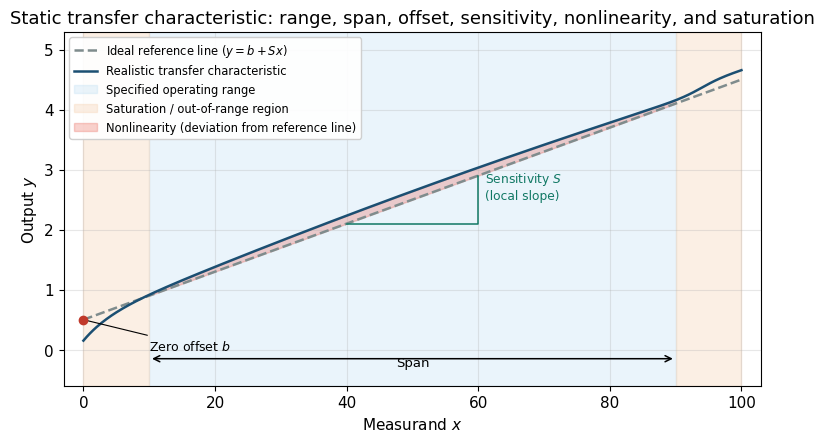

In [3]:
x = np.linspace(0, 100, 400)
x_min, x_max = 10, 90
b, S = 0.5, 0.04
y_ideal = b + S * x
y_real = b + S * x + 0.14 * np.sin(np.pi * x / 100) - 0.10 * np.exp(-(x - 5) / 4) \
          + 0.16 / (1 + np.exp(-(x - 94) / 1.6))

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(x, y_ideal, '--', color='#7f8c8d', label='Ideal reference line ($y=b+Sx$)')
ax.plot(x, y_real, color='#1b4f72', label='Realistic transfer characteristic')

ax.axvspan(x_min, x_max, color='#aed6f1', alpha=0.25, label='Specified operating range')
ax.axvspan(0, x_min, color='#f5cba7', alpha=0.3)
ax.axvspan(x_max, 100, color='#f5cba7', alpha=0.3, label='Saturation / out-of-range region')

y_span_level = -0.15
ax.annotate('', xy=(x_max, y_span_level), xytext=(x_min, y_span_level),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.1))
ax.text((x_min + x_max) / 2, y_span_level - 0.13, 'Span', ha='center', fontsize=9.5)

ax.plot([0], [b], 'o', color='#c0392b', zorder=5)
ax.annotate('Zero offset $b$', xy=(0, b), xytext=(10, b - 0.5),
            fontsize=9, arrowprops=dict(arrowstyle='-', lw=0.8))

x0, x1 = 40, 60
ax.plot([x0, x1, x1], [b + S*x0, b + S*x0, b + S*x1], color='#117864', lw=1.1)
ax.text(x1 + 1, (b + S*x0 + b + S*x1) / 2, 'Sensitivity $S$\n(local slope)', fontsize=8.8, color='#117864')

dev_x = x[(x >= x_min) & (x <= x_max)]
dev_ideal = y_ideal[(x >= x_min) & (x <= x_max)]
dev_real = y_real[(x >= x_min) & (x <= x_max)]
ax.fill_between(dev_x, dev_ideal, dev_real, color='#e74c3c', alpha=0.25, label='Nonlinearity (deviation from reference line)')

ax.set(xlabel='Measurand $x$', ylabel='Output $y$',
       title='Static transfer characteristic: range, span, offset, sensitivity, nonlinearity, and saturation')
ax.set_xlim(-3, 103)
ax.set_ylim(-0.6, 5.3)
ax.legend(loc='upper left', fontsize=8.3, framealpha=0.92)
plt.savefig('fig_9_2_transfer_concept.png')
plt.show()


---
## Theory illustration 3 — Step response and bandwidth (Figure 9.3)

The same first-order dynamic limitation viewed in the time domain (step
response) and the frequency domain ($-3$ dB roll-off). Used in Section
9.2.6 of the chapter.

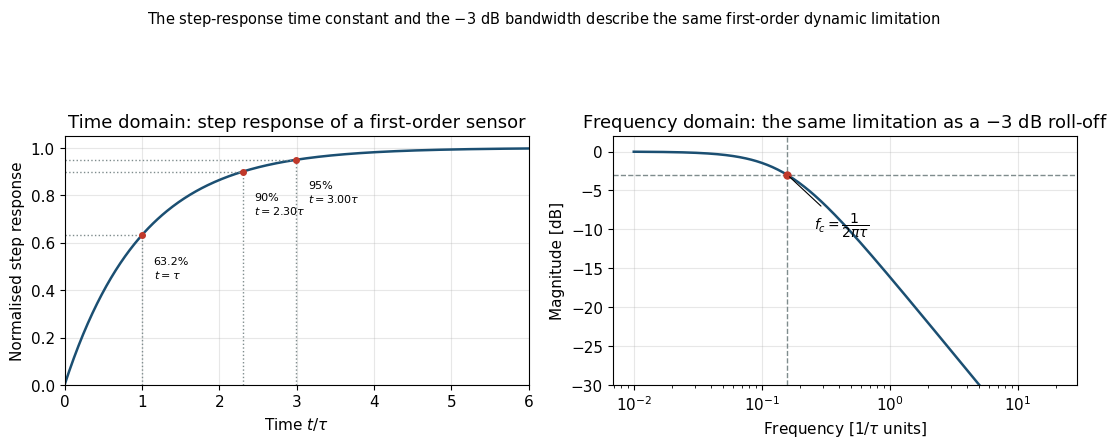

In [4]:
tau = 1.0
t_c = np.linspace(0, 6, 400)
y_c = 1 - np.exp(-t_c / tau)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.plot(t_c, y_c, color='#1b4f72')
for level, label in [(0.632, '63.2%'), (0.90, '90%'), (0.95, '95%')]:
    t_level = -tau * np.log(1 - level)
    ax.plot([t_level, t_level], [0, level], ':', color='#7f8c8d', lw=1)
    ax.plot([0, t_level], [level, level], ':', color='#7f8c8d', lw=1)
    ax.plot([t_level], [level], 'o', color='#c0392b', ms=4)
    lab = f'{label}\n$t=\\tau$' if abs(t_level - tau) < 0.05 else f'{label}\n$t={t_level:.2f}\\tau$'
    ax.annotate(lab, xy=(t_level, level), xytext=(t_level + 0.15, level - 0.18), fontsize=8)
ax.set(xlabel=r'Time $t/\tau$', ylabel='Normalised step response',
       title='Time domain: step response of a first-order sensor')
ax.set_xlim(0, 6)
ax.set_ylim(0, 1.05)

ax = axes[1]
f = np.logspace(-2, 1.3, 400)
mag_db = 20 * np.log10(1 / np.sqrt(1 + (2 * np.pi * f * tau) ** 2))
ax.semilogx(f, mag_db, color='#1b4f72')
fc = 1 / (2 * np.pi * tau)
ax.axhline(-3, ls='--', color='#7f8c8d', lw=1)
ax.axvline(fc, ls='--', color='#7f8c8d', lw=1)
ax.plot([fc], [-3], 'o', color='#c0392b', ms=5)
ax.annotate(r'$f_c=\dfrac{1}{2\pi\tau}$', xy=(fc, -3), xytext=(fc * 1.6, -10),
            fontsize=10, arrowprops=dict(arrowstyle='-', lw=0.8))
ax.set(xlabel='Frequency [1/$\\tau$ units]', ylabel='Magnitude [dB]',
       title='Frequency domain: the same limitation as a $-3$ dB roll-off')
ax.set_ylim(-30, 2)

fig.suptitle('The step-response time constant and the $-3$ dB bandwidth describe the same first-order dynamic limitation',
             fontsize=10.5, y=1.06)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('fig_9_3_dynamics_concept.png')
plt.show()


---
## Exercise 9.1 — Accuracy, precision, and resolution are different properties

### Background
Three hypothetical sensors repeatedly observe the same reference value.
Sensor A is designed to be highly repeatable but biased, Sensor B nearly
unbiased but noisy, and Sensor C low-noise but coarsely quantised. The
exercise first studies a constant reference and then a slowly varying
ramp, which separates the statistical scatter of repeated readings
(precision, specifically repeatability, since all readings are taken under
the same conditions) from systematic displacement (bias) and from the
smallest indicated step (resolution).

In [5]:
true_ref = 37.4
n = 500
configs = {
    'A: precise, biased': dict(bias=1.2, sigma=0.18, resolution=0.1),
    'B: nearly unbiased, noisy': dict(bias=0.05, sigma=0.85, resolution=0.1),
    'C: low-noise, coarse resolution': dict(bias=0.10, sigma=0.10, resolution=0.5),
}

rows, readings = [], {}
for name, c in configs.items():
    y = true_ref + c['bias'] + rng.normal(0, c['sigma'], n)
    y = np.round(y / c['resolution']) * c['resolution']
    readings[name] = y
    rows.append({
        'Sensor': name,
        'Configured bias': c['bias'],
        'Mean indication': y.mean(),
        'Estimated bias': y.mean() - true_ref,
        'Sample SD under repeatability conditions': y.std(ddof=1),
        'RMSE': np.sqrt(np.mean((y - true_ref) ** 2)),
        'Unique indicated values': len(np.unique(y)),
    })
metrics_91 = pd.DataFrame(rows)
metrics_91


,Sensor,Configured bias,Mean indication,Estimated bias,Sample SD under repeatability conditions,RMSE,Unique indicated values
0,"A: precise, biased",1.20,38.596,1.196,0.178571,1.209231,11
1,"B: nearly unbiased, noisy",0.05,37.413,0.013,0.866899,0.866129,47
2,"C: low-noise, coarse resolution",0.10,37.498,0.098,0.054791,0.112250,3


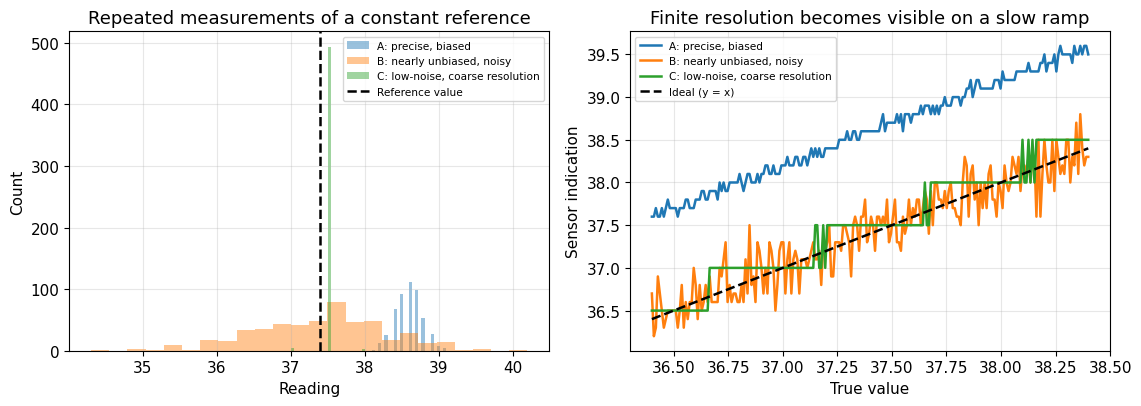

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax = axes[0]
for name, y in readings.items():
    ax.hist(y, bins=24, alpha=0.45, label=name)
ax.axvline(true_ref, linestyle='--', color='k', label='Reference value')
ax.set(xlabel='Reading', ylabel='Count', title='Repeated measurements of a constant reference')
ax.legend(fontsize=7.6)

ax = axes[1]
x = np.linspace(36.4, 38.4, 220)
for name, c in configs.items():
    y = x + c['bias'] + rng.normal(0, c['sigma'] * 0.25, len(x))
    y = np.round(y / c['resolution']) * c['resolution']
    ax.plot(x, y, label=name)
ax.plot(x, x, '--', color='k', label='Ideal (y = x)')
ax.set(xlabel='True value', ylabel='Sensor indication', title='Finite resolution becomes visible on a slow ramp')
ax.legend(fontsize=7.6)
plt.tight_layout()
plt.savefig('fig_9_4_ex1_accuracy_precision_resolution.png')
plt.show()


### Analysis
Sensor A forms a narrow distribution (high precision under repeatability
conditions) whose centre is displaced from the reference: it is repeatable
but biased. Sensor B's *estimated* bias (+0.013) is much smaller than its
*configured* bias (0.05); this is not a contradiction but ordinary sampling
variability — with $n=500$ and $\sigma=0.85$, the standard error of the
mean is $0.85/\sqrt{500}\approx 0.038$, so an estimate within about one
standard error of the configured value is expected. The lesson is that a
single sample's estimated bias should not be read off as if it were the
sensor's true systematic error. Sensor C demonstrates a separate
limitation: low noise does not imply fine resolution — the ramp plot shows
its indication staying flat over a range of true values before stepping.
RMSE is reported for completeness but is not itself a measure of accuracy:
it combines both the systematic (bias) and random (repeatability)
components into a single number, so two sensors with the same RMSE can
have very different bias/precision trade-offs.

**Challenge tasks.** Change only one parameter at a time — bias, random
noise, or resolution — and identify which metric and which plot changes.
Then increase the sample count by a factor of ten. Does a larger dataset
remove bias? Does it improve the physical resolution of the sensor?

---
## Exercise 9.2 — Static transfer characteristic: sensitivity, nonlinearity, and hysteresis

### Background
A static sweep is one of the most informative sensor characterisation
experiments. The simulated sensor has a nominal 0.5–4.5 V output over an
input range of 0–100 units, with small deterministic nonlinearity and
direction-dependent hysteresis. The input is swept upward and downward,
and the centre of the two curves is approximated by a best-fit line.

Two independent conventions are used and must not be confused: (1) the
best-fit line is used **only** as the *reference line* against which
nonlinearity is measured — an endpoint line would give a different
numerical nonlinearity from the same data; (2) the **nominal output span**
(0.5–4.5 V $\Rightarrow$ 4.0 V), not the fitted line's own endpoint span,
is used as the %FSO normalising denominator, since that is what a
datasheet's FSO specification is normally expressed against.

In [7]:
x = np.linspace(0, 100, 201)
span_param = 4.0
b0 = 0.5
nominal_sensitivity = 0.04
fso_nominal = 4.0   # nominal output span, 0.5-4.5 V -> 4.0 V, stated explicitly

nonlinearity_term = 0.008 * span_param * np.sin(np.pi * x / 100) * np.sin(2 * np.pi * x / 100)
hyst_shape = 1 - (2 * x / 100 - 1) ** 2
hyst_half = 0.003 * span_param * hyst_shape
centre = b0 + nominal_sensitivity * x + nonlinearity_term
up = centre - hyst_half
down = centre + hyst_half

p = np.polyfit(x, (up + down) / 2, 1)
fit = np.polyval(p, x)

max_nl_pct = np.max(np.abs((up + down) / 2 - fit)) / fso_nominal * 100
max_hyst_pct = np.max(np.abs(down - up)) / fso_nominal * 100

metrics_92 = pd.DataFrame({
    'Estimated sensitivity [V/unit]': [p[0]],
    'Estimated offset [V]': [p[1]],
    'Nominal FSO used for %FSO [V]': [fso_nominal],
    'Max nonlinearity [% FSO]': [max_nl_pct],
    'Max hysteresis [% FSO]': [max_hyst_pct],
})
metrics_92


,Estimated sensitivity [V/unit],Estimated offset [V],Nominal FSO used for %FSO [V],Max nonlinearity [% FSO],Max hysteresis [% FSO]
0,0.039659,0.517036,4.0,0.458703,0.6


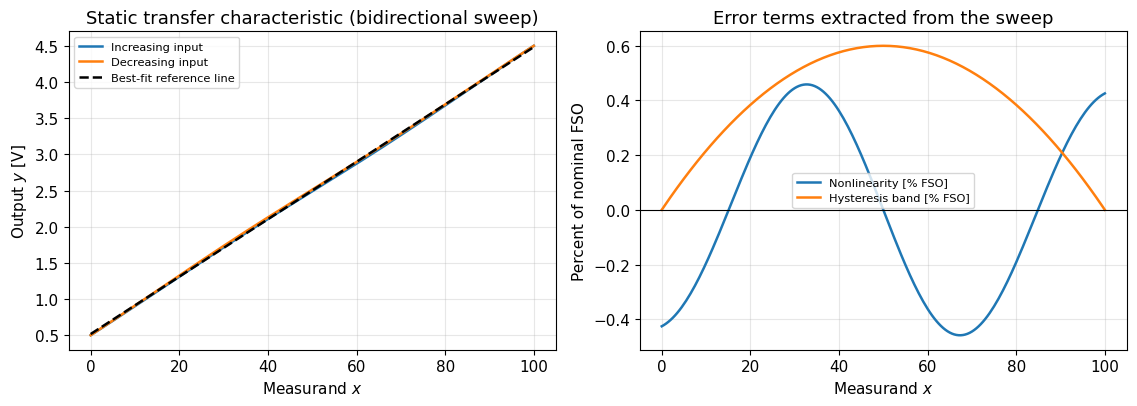

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax = axes[0]
ax.plot(x, up, label='Increasing input')
ax.plot(x, down, label='Decreasing input')
ax.plot(x, fit, '--', color='k', label='Best-fit reference line')
ax.set(xlabel='Measurand $x$', ylabel='Output $y$ [V]', title='Static transfer characteristic (bidirectional sweep)')
ax.legend(fontsize=8.2)

ax = axes[1]
ax.plot(x, 100 * ((up + down) / 2 - fit) / fso_nominal, label='Nonlinearity [% FSO]')
ax.plot(x, 100 * (down - up) / fso_nominal, label='Hysteresis band [% FSO]')
ax.axhline(0, linewidth=0.8, color='k')
ax.set(xlabel='Measurand $x$', ylabel='Percent of nominal FSO', title='Error terms extracted from the sweep')
ax.legend(fontsize=8.2)
plt.tight_layout()
plt.savefig('fig_9_5_ex2_static_characteristic.png')
plt.show()


### Analysis
The exercise shows why a sensor's "linearity" number cannot be interpreted
without knowing the reference-line convention, and why the %FSO
denominator must also be stated: normalising by the nominal 4.0 V span
gives 0.459% FSO nonlinearity and 0.600% FSO hysteresis, both slightly
different from what normalising by the fitted line's own endpoint span
would give. It also shows why hysteresis cannot be discovered from a
one-direction sweep. Two devices could have the same nominal sensitivity
yet differ substantially in nonlinearity and history dependence.

**Challenge tasks.** Replace the best-fit reference line with the line
through the two endpoints and recalculate nonlinearity. Then double only
the hysteresis term. Which reported characteristics change and which
remain almost unchanged?

---
## Exercise 9.3 — Dynamic response: time constant and bandwidth

### Background
Three first-order sensors observe the same step from 20 to 80 units. Their
time constants are 0.5, 2, and 5 s. The notebook estimates the time to
63.2%, 90%, and 95% of the final change, and plots the corresponding
frequency responses.

### Model
The continuous model $\tau\dot y + y = x$ is simulated with the exact
discrete-time first-order update for a zero-order-held input,
$y_k = y_{k-1} + (1-e^{-\Delta t/\tau})(x_k - y_{k-1})$.

To keep the indexing unambiguous, the simulation is split into two
independent phases rather than run on one continuous time array with an
embedded step. Before the step the sensor sits at steady state and is
simply drawn as a constant 20 — it is not part of the recursion. After
the step, a fresh time array `t_post` is defined so that `t_post = 0`
**is** the step instant, with initial condition `y_post[0] = 20`; the
recursion is then applied for $k=1,2,\dots$ with the input held at 80.
Because `t_post = 0` and the step coincide exactly by construction, every
rise-time metric is read directly off `t_post` with no timing-reference
correction of any kind. The theoretical bandwidth is $f_c=1/(2\pi\tau)$.

In [9]:
dt = 0.02
taus = [0.5, 2.0, 5.0]
linestyles = ['-', '--', '-.']
responses_post = {}
rows = []

for tau in taus:
    t_post = np.arange(0, 25 + dt, dt)      # elapsed time since the step; t_post=0 IS the step
    y_post = np.empty_like(t_post)
    y_post[0] = 20.0                        # value at the instant of the step
    a = 1 - np.exp(-dt / tau)
    for k in range(1, len(t_post)):
        y_post[k] = y_post[k - 1] + a * (80.0 - y_post[k - 1])
    responses_post[tau] = (t_post, y_post)

    normed = (y_post - 20) / 60             # rise-time metrics read directly off t_post

    def first_time(level, tt=t_post, normed=normed):
        idx = np.where(normed >= level)[0]
        return tt[idx[0]] if len(idx) else np.nan

    rows.append({'tau [s]': tau, 't63 [s]': first_time(0.632), 't90 [s]': first_time(0.90),
                 't95 [s]': first_time(0.95), 'fc [Hz]': 1 / (2 * np.pi * tau)})
metrics_93 = pd.DataFrame(rows)
metrics_93


,tau [s],t63 [s],t90 [s],t95 [s],fc [Hz]
0,0.5,0.5,1.16,1.50,0.318310
1,2.0,2.0,4.62,6.00,0.079577
2,5.0,5.0,11.52,14.98,0.031831


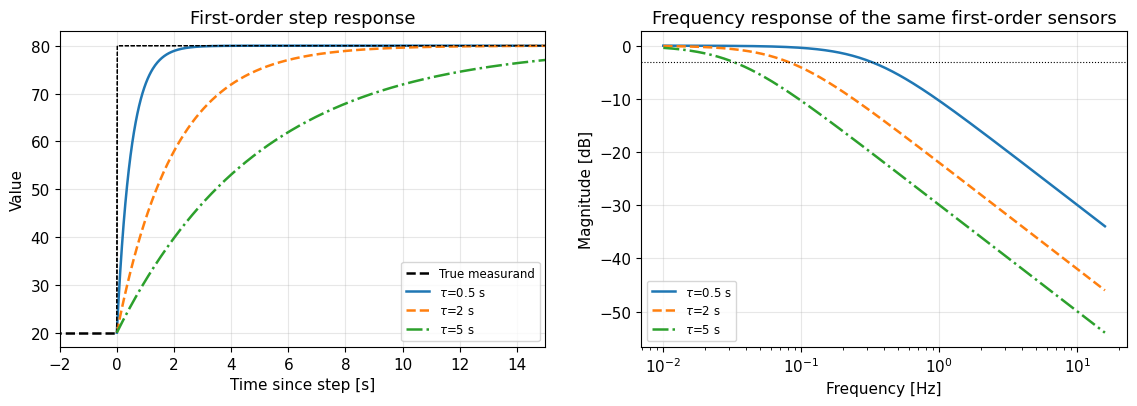

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax = axes[0]
t_pre = np.arange(-5, 0, dt)
ax.plot(np.concatenate([t_pre, [0]]), np.concatenate([np.full_like(t_pre, 20.0), [20.0]]),
        '--', color='k', label='True measurand')
for tau, ls in zip(taus, linestyles):
    t_post, y_post = responses_post[tau]
    ax.plot(t_post, np.where(t_post > 0, 80.0, 20.0), '--', color='k', linewidth=0.8)
    ax.plot(t_post, y_post, linestyle=ls, label=f'$\\tau$={tau:g} s')
ax.set_xlim(-2, 15)
ax.set(xlabel='Time since step [s]', ylabel='Value', title='First-order step response')
ax.legend(fontsize=8.5)

ax = axes[1]
f = np.logspace(-2, 1.2, 400)
for tau, ls in zip(taus, linestyles):
    mag = 1 / np.sqrt(1 + (2 * np.pi * f * tau) ** 2)
    ax.semilogx(f, 20 * np.log10(mag), linestyle=ls, label=f'$\\tau$={tau:g} s')
ax.axhline(-3, linestyle=':', linewidth=0.8, color='k')
ax.set(xlabel='Frequency [Hz]', ylabel='Magnitude [dB]', title='Frequency response of the same first-order sensors')
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig('fig_9_6_ex3_dynamic_response.png')
plt.show()


### Analysis
The measured $t_{63}$ values are 0.50, 2.00, and 5.00 s — matching the
selected time constants to within ordinary rounding, exactly as they
should, since the simulation now has no artificial timing offset to
correct. The corresponding $-3$ dB bandwidths are approximately 0.318,
0.0796, and 0.0318 Hz. The slowest sensor requires about 15 s
($t_{95}\approx14.98$ s) to reach 95% of the final step. The same
physical limitation appears as lag in the time domain and as attenuation
in the frequency domain: if an application needs to detect short
transients, a slow sensor can fail even when its static accuracy is
excellent. Conversely, choosing an unnecessarily wide bandwidth can
expose more noise and consume more power than the application needs.

**Challenge tasks.** Drive the model with a sinusoid rather than a step and
measure attenuation and phase lag. Determine the largest $\tau$ that keeps
attenuation below 1 dB at 1 Hz. Compare the result with the simple $-3$ dB
bandwidth criterion.

---
## Exercise 9.4 — Sensitivity, noise floor, and minimum detectable change

### Background
Three hypothetical sensor designs have different sensitivity and
output-noise combinations. A one-sided alarm threshold is placed
$3\sigma_y$ above the baseline; under a Gaussian model the baseline
false-alarm probability is about 0.135%. The input-referred RMS noise is
$\sigma_x = \sigma_y/|S|$, and the question is which sensor is most
likely to detect a small physical change. All three noise figures below
are stated for the **same measurement bandwidth**, since input-referred
noise is only comparable across sensors when that condition holds.

In [11]:
sensors = {
    'A: high sensitivity, moderate noise': (0.020, 0.0030),
    'B: very high sensitivity, high noise': (0.050, 0.0100),
    'C: lower sensitivity, very low noise': (0.010, 0.0008),
}

def Phi(z):
    z = np.asarray(z, dtype=float)
    return 0.5 * (1 + np.vectorize(erf)(z / np.sqrt(2)))

delta = np.linspace(0, 1.25, 500)
rows = []
z95 = 1.6448536269514722  # one-sided 95th percentile of the standard normal
for name, (S, sigma_y) in sensors.items():
    sigma_x = sigma_y / abs(S)
    delta95 = (3 + z95) * sigma_x
    rows.append({'Sensor': name, 'Sensitivity [V/unit]': S, 'Output noise RMS [V]': sigma_y,
                 'Input-referred noise sigma_x [unit]': sigma_x,
                 'Change for 95% detection [unit]': delta95})
metrics_94 = pd.DataFrame(rows)
metrics_94


,Sensor,Sensitivity [V/unit],Output noise RMS [V],Input-referred noise sigma_x [unit],Change for 95% detection [unit]
0,"A: high sensitivity, moderate noise",0.02,0.0030,0.15,0.696728
1,"B: very high sensitivity, high noise",0.05,0.0100,0.20,0.928971
2,"C: lower sensitivity, very low noise",0.01,0.0008,0.08,0.371588


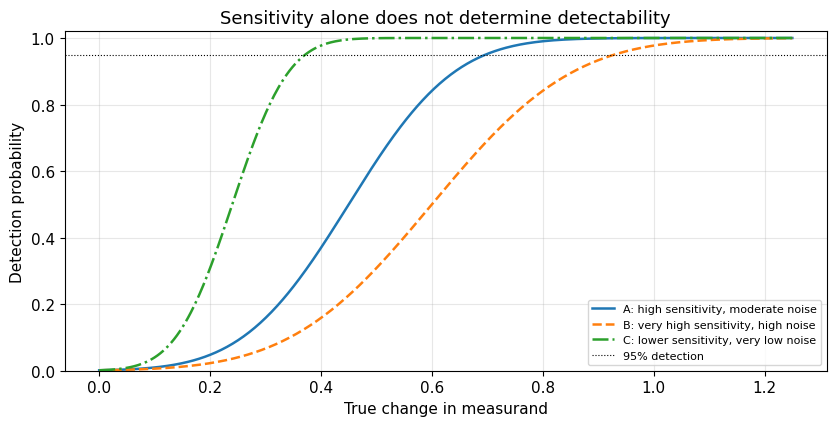

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
detect_linestyles = ['-', '--', '-.']
for (name, (S, sigma_y)), ls in zip(sensors.items(), detect_linestyles):
    sigma_x = sigma_y / abs(S)
    z = 3 - delta / sigma_x
    p_detect = 1 - Phi(z)
    ax.plot(delta, p_detect, linestyle=ls, label=name)
ax.axhline(0.95, linestyle=':', linewidth=0.8, color='k', label='95% detection')
ax.set(xlabel='True change in measurand', ylabel='Detection probability',
       title='Sensitivity alone does not determine detectability', ylim=(0, 1.02))
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig_9_7_ex4_detectability.png')
plt.show()


### Analysis
Sensor B has the largest electrical sensitivity (0.05 V/unit) but also the
largest output noise (0.01 V RMS), giving the worst input-referred noise
(0.20 units) and requiring the largest change (about 0.93 units) for 95%
detection. Sensor C has the smallest electrical sensitivity (0.01 V/unit)
but by far the lowest output noise (0.0008 V RMS), giving the best
input-referred noise (0.08 units) and the smallest required change (about
0.37 units). Sensor A sits between the two (0.15 units, about 0.70 units
for 95% detection). The table directly contradicts the simplistic rule
"choose the most sensitive sensor": what matters for small-signal
detection is how the expected response compares with noise, not
electrical sensitivity on its own. The same reasoning applies to optical,
chemical, acoustic, inertial, and biomedical sensors, even though their
physical noise sources differ.

**Challenge tasks.** Move the threshold from $3\sigma$ to $4\sigma$ and
quantify the new false-alarm/detection trade-off. Then add slow baseline
drift. Why does a fixed threshold become unreliable, and what additional
procedures would be required? Chapter 16 develops those procedures in
detail.

---
## Practice summary

The four exercises build a compact sensor-characterisation workflow:

- repeated reference measurements separate **bias** from **repeatability**,
  and show that a single sample's estimated bias can differ from the
  sensor's configured (true) bias by an amount consistent with ordinary
  sampling variability;
- a slow input ramp reveals **resolution** as a limitation distinct from
  noise;
- a bidirectional static sweep exposes **sensitivity**, **nonlinearity**,
  and **hysteresis**, and shows that both the reference-line convention
  and the %FSO normalising denominator must be stated explicitly;
- a step response connects **time constant** to **bandwidth**, using an
  elapsed-time-since-step formulation chosen so that no timing-reference
  correction is needed;
- **input-referred noise** links sensitivity and output noise into a
  single figure of merit for detectability, valid for comparison only
  when sensors are evaluated over the same measurement bandwidth.

These tools are deliberately generic so that the same reasoning can be
reused for the specific sensor technologies in Chapters 10–16.